# Euler–Maruyama convergence

The Euler–Maruyama scheme has strong order $1/2$ and weak order $1$. We verify both on geometric Brownian motion, whose closed-form solution gives a path-wise reference: the **strong error** is the root-mean-square deviation at the final time, the **weak error** the gap between the means of a test function. A log-log fit of error against $\Delta t$ recovers the predicted slopes (report Sections 4.1, 12).

In [1]:
import sys
from pathlib import Path

# Locate the project root (the folder containing src/) so the solver modules
# import cleanly and figures are written to figures/.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
FIGURES = ROOT / "figures"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sde

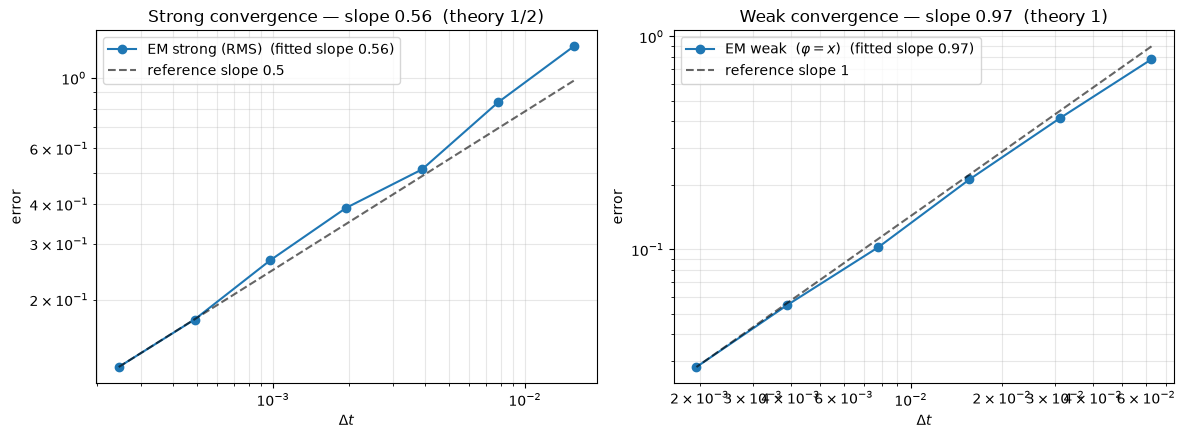

strong slope = 0.556   (Euler-Maruyama theory: 1/2)
weak   slope = 0.966   (Euler-Maruyama theory: 1)


In [3]:
X0, mu, sigma, T = 1.0, 2.0, 1.0, 1.0
f, g = sde.gbm(mu, sigma)
scheme = lambda T, N, M, rng: sde.euler_maruyama(f, g, X0, T, N, M=M, rng=rng, return_dW=True)
exact = lambda t, W: sde.gbm_exact(X0, mu, sigma, t, W)

Ns_strong = [64, 128, 256, 512, 1024, 2048, 4096]   # dt from 1/64 down to 1/4096
Ns_weak = [16, 32, 64, 128, 256, 512]

ds, es, slope_s, _ = sde.convergence_study(
    lambda N: sde.strong_error(scheme, exact, T, N, M=6000, rng=np.random.default_rng(0)),
    Ns_strong, T)
dw, ew, slope_w, _ = sde.convergence_study(
    lambda N: sde.weak_error(scheme, exact, lambda x: x, T, N, M=30000, rng=np.random.default_rng(10)),
    Ns_weak, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sde.loglog_convergence(ds, es, slope_s, "EM strong (RMS)", ref_order=0.5, ax=axes[0])
axes[0].set_title(f"Strong convergence \u2014 slope {slope_s:.2f}  (theory 1/2)")
sde.loglog_convergence(dw, ew, slope_w, r"EM weak  ($\varphi=x$)", ref_order=1.0, ax=axes[1])
axes[1].set_title(f"Weak convergence \u2014 slope {slope_w:.2f}  (theory 1)")
fig.tight_layout()
fig.savefig(FIGURES / "m2r_convergence.png", dpi=120)
plt.show()

print(f"strong slope = {slope_s:.3f}   (Euler-Maruyama theory: 1/2)")
print(f"weak   slope = {slope_w:.3f}   (Euler-Maruyama theory: 1)")